In [3]:
import pandas as pd 
from mlxtend.frequent_patterns import apriori, association_rules 

In [30]:
df=pd.read_csv("Dataset 1 CSV.csv")
df.head()


,Member_number,Date,Transaction_ID,itemDescription,year,month,day,day_of_week
0,1000,24/06/2014,1000_41814,whole milk,2014,6,24,1
1,1000,24/06/2014,1000_41814,pastry,2014,6,24,1
2,1000,24/06/2014,1000_41814,salty snack,2014,6,24,1
3,1000,15/03/2015,1000_42078,sausage,2015,3,15,6
4,1000,15/03/2015,1000_42078,whole milk,2015,3,15,6


In [31]:
df.columns

Index(['Member_number', 'Date', 'Transaction_ID', 'itemDescription', 'year',
       'month', 'day', 'day_of_week'],
      dtype='object')

In [32]:
basket=df.groupby(['Transaction_ID', 'itemDescription'])['itemDescription'].count().unstack().fillna(0)


In [34]:
basket=basket.applymap(lambda x:1 if x>0 else 0)
basket.head()

C:\Users\elfer\AppData\Local\Temp\ipykernel_10196\1125632947.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket=basket.applymap(lambda x:1 if x>0 else 0)


itemDescription,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
Transaction_ID,,,,,,,,,,,,,,,,,,,,,
1000_41814,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1000_42078,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0
1000_42151,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1000_42209,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1000_42333,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [37]:
frequent_itemsets=apriori(basket, min_support=0.001, use_colnames=True)
frequent_itemsets.head()

frequent_itemsets.sort_values(
    by="support",
    ascending=False
).head(20)

C:\Users\elfer\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
146,0.157923,(whole milk)
90,0.122101,(other vegetables)
109,0.110005,(rolls/buns)
123,0.097106,(soda)
147,0.085879,(yogurt)
110,0.069572,(root vegetables)
139,0.067767,(tropical fruit)
10,0.060683,(bottled water)
115,0.060349,(sausage)
28,0.053131,(citrus fruit)


In [39]:
rules=association_rules(frequent_itemsets, metric="confidence", min_threshold=0.001)
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(bottled water),(UHT-milk),0.060683,0.021386,0.001069,0.017621,0.823954,1.0,-0.000228,0.996168,-0.185312,0.013201,-0.003847,0.033811
1,(UHT-milk),(bottled water),0.021386,0.060683,0.001069,0.050000,0.823954,1.0,-0.000228,0.988755,-0.179204,0.013201,-0.011373,0.033811
2,(other vegetables),(UHT-milk),0.122101,0.021386,0.002139,0.017515,0.818993,1.0,-0.000473,0.996060,-0.201119,0.015130,-0.003956,0.058758
3,(UHT-milk),(other vegetables),0.021386,0.122101,0.002139,0.100000,0.818993,1.0,-0.000473,0.975443,-0.184234,0.015130,-0.025175,0.058758
4,(rolls/buns),(UHT-milk),0.110005,0.021386,0.001804,0.016403,0.767013,1.0,-0.000548,0.994934,-0.254457,0.013925,-0.005092,0.050389


In [40]:
basket=basket.astype(bool)

In [42]:
frequent_itemsets=apriori(basket, min_support=0.001, use_colnames=True)
frequent_itemsets.head()


,support,itemsets
0,0.004010,(Instant food products)
1,0.021386,(UHT-milk)
2,0.001470,(abrasive cleaner)
3,0.001938,(artif. sweetener)
4,0.008087,(baking powder)


In [44]:
frequent_itemsets['length']=frequent_itemsets['itemsets'].apply(lambda x:len(x))
frequent_itemsets['length'].value_counts()


length
2    592
1    149
3      9
Name: count, dtype: int64

In [46]:
rules=association_rules(frequent_itemsets, metric="confidence", min_threshold=0.001)
rules.head()


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(bottled water),(UHT-milk),0.060683,0.021386,0.001069,0.017621,0.823954,1.0,-0.000228,0.996168,-0.185312,0.013201,-0.003847,0.033811
1,(UHT-milk),(bottled water),0.021386,0.060683,0.001069,0.050000,0.823954,1.0,-0.000228,0.988755,-0.179204,0.013201,-0.011373,0.033811
2,(other vegetables),(UHT-milk),0.122101,0.021386,0.002139,0.017515,0.818993,1.0,-0.000473,0.996060,-0.201119,0.015130,-0.003956,0.058758
3,(UHT-milk),(other vegetables),0.021386,0.122101,0.002139,0.100000,0.818993,1.0,-0.000473,0.975443,-0.184234,0.015130,-0.025175,0.058758
4,(rolls/buns),(UHT-milk),0.110005,0.021386,0.001804,0.016403,0.767013,1.0,-0.000548,0.994934,-0.254457,0.013925,-0.005092,0.050389


In [23]:
len(rules)


1238

In [47]:
rules.sort_values(by="lift", ascending=False).head(10)

table_42 = rules.sort_values(
    by="lift",
    ascending=False
)[["antecedents","consequents","support","confidence","lift"]].head(6)

table_42


,antecedents,consequents,support,confidence,lift
1236,(sausage),"(whole milk, yogurt)",0.001470,0.024363,2.182917
1233,"(whole milk, yogurt)",(sausage),0.001470,0.131737,2.182917
1232,"(whole milk, sausage)",(yogurt),0.001470,0.164179,1.911760
1237,(yogurt),"(whole milk, sausage)",0.001470,0.017121,1.911760
474,(citrus fruit),(specialty chocolate),0.001403,0.026415,1.653762
475,(specialty chocolate),(citrus fruit),0.001403,0.087866,1.653762


In [6]:
print(df["month"].unique())

[ 6  3  5  7 11 12  1  2  4  9  8 10]


In [7]:
print(df["day_of_week"].unique())

[1 6 2 4 3 5 0]


In [8]:
df["month"].value_counts().sort_index()

month
1     3333
2     3032
3     3283
4     3172
5     3335
6     3316
7     3268
8     3498
9     2963
10    3218
11    3273
12    3074
Name: count, dtype: int64

In [9]:
df.groupby("month")["itemDescription"].value_counts().groupby(level=0).head(10)

month  itemDescription 
1      whole milk          219
       other vegetables    166
       rolls/buns          149
       soda                134
       yogurt              112
                          ... 
12     yogurt               98
       bottled water        84
       tropical fruit       78
       sausage              77
       shopping bags        68
Name: count, Length: 120, dtype: int64

In [10]:
top_products=df.groupby("month")["itemDescription"]\
.value_counts()\
.groupby(level=0)\
.head(5)

print(top_products.to_string())

month  itemDescription 
1      whole milk          219
       other vegetables    166
       rolls/buns          149
       soda                134
       yogurt              112
2      whole milk          173
       rolls/buns          159
       other vegetables    144
       soda                107
       yogurt               95
3      whole milk          216
       other vegetables    145
       rolls/buns          141
       yogurt              127
       soda                125
4      whole milk          218
       other vegetables    155
       yogurt              137
       soda                135
       rolls/buns          126
5      whole milk          218
       other vegetables    145
       rolls/buns          142
       soda                115
       yogurt              103
6      whole milk          205
       other vegetables    159
       rolls/buns          150
       soda                145
       yogurt              100
7      whole milk          222
       other ve

In [17]:
df[df["month"] == 1].head()

,Member_number,Date,Transaction_ID,itemDescription,year,month,day,day_of_week
18,1001,20/01/2015,1001_42024,frankfurter,2015,1,20,1
19,1001,20/01/2015,1001_42024,soda,2015,1,20,1
20,1001,20/01/2015,1001_42024,whipped/sour cream,2015,1,20,1
33,1003,19/01/2014,1003_41658,frozen meals,2014,1,19,6
34,1003,19/01/2014,1003_41658,dental care,2014,1,19,6


In [11]:
month1=df[df["month"]==1]

basket_month1=(month1.groupby(['Transaction_ID','itemDescription'])['itemDescription']
              .count()
              .unstack()
              .fillna(0))

basket_month1=basket_month1.map(lambda x:1 if x>0 else 0)

basket_month1.head()


itemDescription,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baking powder,beef,berries,beverages,bottled beer,bottled water,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
Transaction_ID,,,,,,,,,,,,,,,,,,,,,
1001_42024,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1003_41658,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1004_41644,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1004_41646,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1005_41662,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [14]:
basket_month1=basket_month1.astype(bool)

frequent_itemsets_month1= apriori(
    basket_month1,
    min_support=0.001,
    use_colnames=True
)

frequent_itemsets_month1.head()


,support,itemsets
0,0.003873,(Instant food products)
1,0.015492,(UHT-milk)
2,0.002324,(artif. sweetener)
3,0.005422,(baking powder)
4,0.034857,(beef)


In [15]:
frequent_itemsets_month1 ['length']=frequent_itemsets_month1['itemsets'].apply(lambda x: len(x))
frequent_itemsets_month1['length'].value_counts()


length
2    597
1    137
3     76
4      4
Name: count, dtype: int64

In [16]:
rules_month1=association_rules(
    frequent_itemsets_month1,
    metric="confidence",
    min_threshold=0.001
)

rules_month1.head()


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(bottled beer),(UHT-milk),0.049574,0.015492,0.001549,0.031250,2.017187,1.0,0.000781,1.016266,0.530562,0.024390,0.016006,0.065625
1,(UHT-milk),(bottled beer),0.015492,0.049574,0.001549,0.100000,2.017187,1.0,0.000781,1.056029,0.512195,0.024390,0.053056,0.065625
2,(frankfurter),(UHT-milk),0.038730,0.015492,0.001549,0.040000,2.582000,1.0,0.000949,1.025529,0.637389,0.029412,0.024894,0.070000
3,(UHT-milk),(frankfurter),0.015492,0.038730,0.001549,0.100000,2.582000,1.0,0.000949,1.068078,0.622345,0.029412,0.063739,0.070000
4,(misc. beverages),(UHT-milk),0.021689,0.015492,0.001549,0.071429,4.610714,1.0,0.001213,1.060240,0.800475,0.043478,0.056817,0.085714


In [17]:
len(rules_month1)

1706

In [18]:
rules_month1.sort_values(by="lift", ascending=False).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1659,"(frankfurter, whipped/sour cream)","(dishes, citrus fruit)",0.003098,0.001549,0.001549,0.500000,322.750000,1.0,0.001544,1.996902,1.000000,0.500000,0.499224,0.750000
1654,"(dishes, citrus fruit)","(frankfurter, whipped/sour cream)",0.001549,0.003098,0.001549,1.000000,322.750000,1.0,0.001544,inf,0.998448,0.500000,1.000000,0.750000
1657,"(citrus fruit, frankfurter)","(dishes, whipped/sour cream)",0.003098,0.002324,0.001549,0.500000,215.166667,1.0,0.001542,1.995352,0.998446,0.400000,0.498835,0.583333
1656,"(dishes, whipped/sour cream)","(citrus fruit, frankfurter)",0.002324,0.003098,0.001549,0.666667,215.166667,1.0,0.001542,2.990705,0.997671,0.400000,0.665631,0.583333
1671,"(tropical fruit, other vegetables)","(sausage, whipped/sour cream)",0.009295,0.001549,0.001549,0.166667,107.583333,1.0,0.001535,1.198141,1.000000,0.166667,0.165374,0.583333
1670,"(sausage, whipped/sour cream)","(tropical fruit, other vegetables)",0.001549,0.009295,0.001549,1.000000,107.583333,1.0,0.001535,inf,0.992242,0.166667,1.000000,0.583333
1438,(pickled vegetables),"(rolls/buns, ham)",0.010844,0.001549,0.001549,0.142857,92.214286,1.0,0.001532,1.164859,1.000000,0.142857,0.141527,0.571429
1658,"(citrus fruit, whipped/sour cream)","(dishes, frankfurter)",0.005422,0.003098,0.001549,0.285714,92.214286,1.0,0.001532,1.395662,0.994548,0.222222,0.283494,0.392857
1655,"(dishes, frankfurter)","(citrus fruit, whipped/sour cream)",0.003098,0.005422,0.001549,0.500000,92.214286,1.0,0.001532,1.989156,0.992230,0.222222,0.497274,0.392857
1653,"(citrus fruit, frankfurter, whipped/sour cream)",(dishes),0.001549,0.010844,0.001549,1.000000,92.214286,1.0,0.001532,inf,0.990690,0.142857,1.000000,0.571429


In [19]:
rules_month1[
    rules_month1["support"]>=0.003
    ].sort_values(
        by="lift",
        ascending=False
    ).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
554,(dishes),(frankfurter),0.010844,0.038730,0.003098,0.285714,7.377143,1.0,0.002678,1.345778,0.873923,0.066667,0.256936,0.182857
555,(frankfurter),(dishes),0.038730,0.010844,0.003098,0.080000,7.377143,1.0,0.002678,1.075169,0.899275,0.066667,0.069914,0.182857
1642,(yogurt),"(sausage, whole milk)",0.083656,0.009295,0.004648,0.055556,5.976852,1.0,0.003870,1.048982,0.908707,0.052632,0.046694,0.277778
1639,"(sausage, whole milk)",(yogurt),0.009295,0.083656,0.004648,0.500000,5.976852,1.0,0.003870,1.832688,0.840500,0.052632,0.454353,0.277778
1641,(sausage),"(yogurt, whole milk)",0.058869,0.014717,0.004648,0.078947,5.364266,1.0,0.003781,1.069736,0.864472,0.067416,0.065190,0.197368
1640,"(yogurt, whole milk)",(sausage),0.014717,0.058869,0.004648,0.315789,5.364266,1.0,0.003781,1.375499,0.825734,0.067416,0.272991,0.197368
223,(waffles),(brown bread),0.018590,0.049574,0.004648,0.250000,5.042969,1.0,0.003726,1.267235,0.816890,0.073171,0.210880,0.171875
222,(brown bread),(waffles),0.049574,0.018590,0.004648,0.093750,5.042969,1.0,0.003726,1.082935,0.843521,0.073171,0.076583,0.171875
772,(liquor),(rolls/buns),0.006197,0.110767,0.003098,0.500000,4.513986,1.0,0.002412,1.778466,0.783320,0.027211,0.437718,0.263986
773,(rolls/buns),(liquor),0.110767,0.006197,0.003098,0.027972,4.513986,1.0,0.002412,1.022402,0.875436,0.027211,0.021911,0.263986


In [51]:
results = []

In [52]:
for m in range(1, 13):
    data_month = df[df["month"] == m]

    basket_month = (data_month.groupby(["Transaction_ID", "itemDescription"])["itemDescription"]
                    .count()
                    .unstack()
                    .fillna(0))

    basket_month = basket_month.map(lambda x: 1 if x > 0 else 0)
    basket_month = basket_month.astype(bool)

    frequent_itemsets_month = apriori(
        basket_month,
        min_support=0.001,
        use_colnames=True
    )

    rules_month = association_rules(
        frequent_itemsets_month,
        metric="confidence",
        min_threshold=0.001
    )

    selected_rule = rules_month[
    (rules_month["antecedents"] == frozenset(["whole milk", "yogurt"])) &
    (rules_month["consequents"] == frozenset(["sausage"]))
    ]

    if len(selected_rule) > 0:
        results.append({
            "month": m,
            "support": selected_rule.iloc[0]["support"],
            "confidence": selected_rule.iloc[0]["confidence"],
            "lift": selected_rule.iloc[0]["lift"]
        })
    else:
        results.append({
            "month": m,
            "support": None,
            "confidence": None,
            "lift": None
        })

In [44]:
len(results)

24

In [63]:
results_df = pd.DataFrame(results)
results_df=results_df.fillna(0)
results_df

results_df_final = results_df.tail(12)

results_df_final





,month,support,confidence,lift
0,1,0.004648,0.315789,5.364266
1,2,0.000000,0.000000,0.000000
2,3,0.001621,0.095238,1.366556
3,4,0.002451,0.136364,2.350832
4,5,0.000000,0.000000,0.000000
5,6,0.000000,0.000000,0.000000
6,7,0.000000,0.000000,0.000000
7,8,0.000000,0.000000,0.000000
8,9,0.001748,0.117647,2.102941
9,10,0.000000,0.000000,0.000000


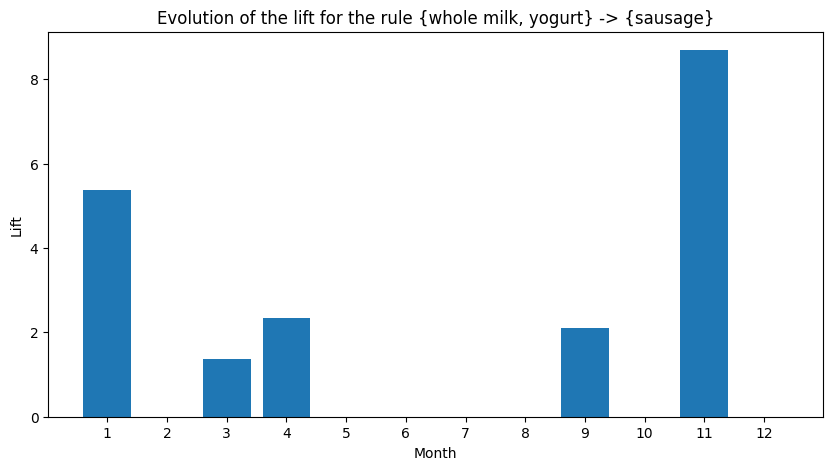

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(results_df["month"],results_df["lift"])

plt.xlabel("Month")
plt.ylabel("Lift")
plt.title("Evolution of the lift for the rule {whole milk, yogurt} -> {sausage}")

plt.xticks(range(1,13))

plt.show()


In [ ]:
results = []

for m in range(1, 13):
    data_month = df[df["month"] == m]

    basket_month = (
        data_month.groupby(["Transaction_ID", "itemDescription"])["itemDescription"]
        .count()
        .unstack()
        .fillna(0)
    )

    basket_month = basket_month.map(lambda x: 1 if x > 0 else 0)
    basket_month = basket_month.astype(bool)

    frequent_itemsets_month = apriori(
        basket_month,
        min_support=0.001,
        use_colnames=True
    )

    rules_month = association_rules(
        frequent_itemsets_month,
        metric="confidence",
        min_threshold=0.001
    )

    selected_rule = rules_month[
        (rules_month["antecedents"] == frozenset(["whole milk", "yogurt"])) &
        (rules_month["consequents"] == frozenset(["sausage"]))
    ]

    if len(selected_rule) > 0:
        results.append({
            "month": m,
            "support": selected_rule.iloc[0]["support"],
            "confidence": selected_rule.iloc[0]["confidence"],
            "lift": selected_rule.iloc[0]["lift"]
        })
    else:
        results.append({
            "month": m,
            "support": 0,
            "confidence": 0,
            "lift": 0
        })

results_df = pd.DataFrame(results)